Epoch 0, Total Loss: 1.050473, PDE: 0.000975, BC: 0.089140, IC: 0.960358
Epoch 1000, Total Loss: 0.000082, PDE: 0.000055, BC: 0.000012, IC: 0.000015
Epoch 2000, Total Loss: 0.000026, PDE: 0.000016, BC: 0.000004, IC: 0.000005
Epoch 3000, Total Loss: 0.000018, PDE: 0.000011, BC: 0.000003, IC: 0.000004
Epoch 4000, Total Loss: 0.000011, PDE: 0.000006, BC: 0.000001, IC: 0.000003
Epoch 5000, Total Loss: 0.000008, PDE: 0.000005, BC: 0.000001, IC: 0.000002
Epoch 6000, Total Loss: 0.000005, PDE: 0.000003, BC: 0.000000, IC: 0.000001
Epoch 7000, Total Loss: 0.000003, PDE: 0.000002, BC: 0.000000, IC: 0.000001
Epoch 8000, Total Loss: 0.000002, PDE: 0.000001, BC: 0.000000, IC: 0.000001
Epoch 9000, Total Loss: 0.000002, PDE: 0.000001, BC: 0.000000, IC: 0.000001


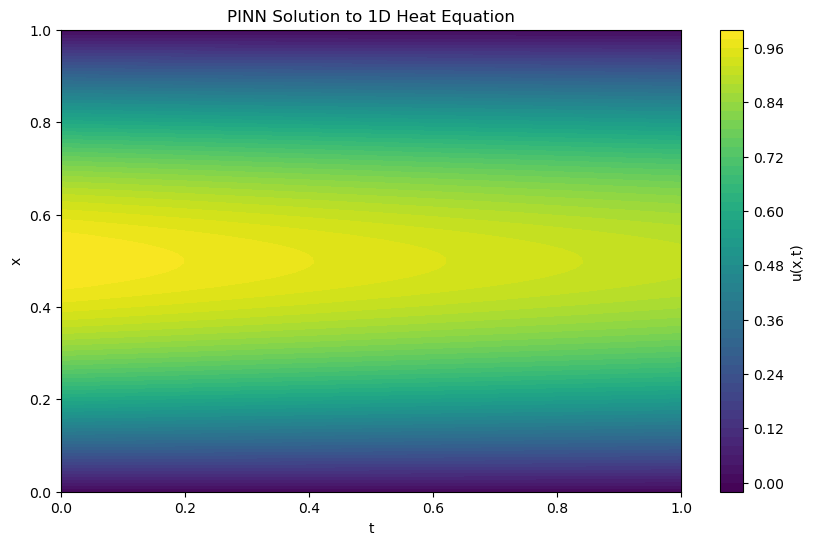

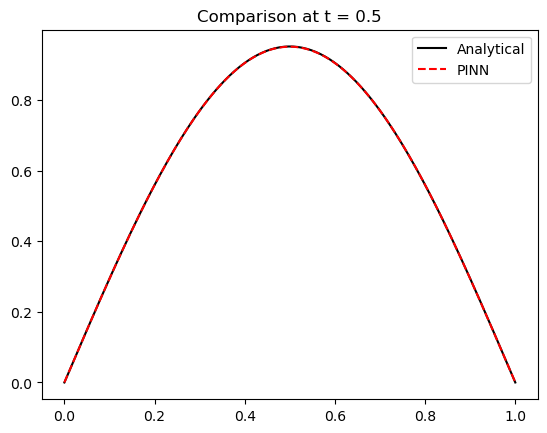

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# PINN model
class PINN(nn.Module):
    def __init__(self, layers=[2, 50, 50, 50, 50, 1]):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers)-2):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
            self.layers.append(nn.Tanh())
        self.layers.append(nn.Linear(layers[-2], layers[-1]))
    
    def forward(self, X):
        for layer in self.layers:
            X = layer(X)
        return X

# Parameters
alpha = 0.01
N_colloc = 10000  # collocation points
N_bc = 200        # boundary points per side
N_ic = 200        # initial condition points

# Sampling points
torch.manual_seed(42)
colloc = torch.rand(N_colloc, 2, requires_grad=True, device=device)
# No scaling needed as torch.rand already produces values in [0, 1)

# Boundary: x=0 and x=1, t in [0,1]
bc_left  = torch.stack([torch.zeros(N_bc), torch.rand(N_bc)], dim=1).to(device)
bc_right = torch.stack([torch.ones(N_bc),  torch.rand(N_bc)], dim=1).to(device)
bc = torch.cat([bc_left, bc_right], dim=0)
bc.requires_grad = False

# Initial: t=0, x in [0,1]
ic = torch.stack([torch.rand(N_ic), torch.zeros(N_ic)], dim=1).to(device)
ic.requires_grad = False
u_ic_true = torch.sin(np.pi * ic[:, 0:1])  # true IC

# Model, optimizer
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # PDE residual
    u_colloc = model(colloc)
    grads = torch.autograd.grad(u_colloc, colloc, grad_outputs=torch.ones_like(u_colloc),
                                create_graph=True, retain_graph=True)[0]
    u_t = grads[:, 1:2]
    u_x = grads[:, 0:1]
    u_xx = torch.autograd.grad(u_x, colloc, grad_outputs=torch.ones_like(u_x),
                               create_graph=True, retain_graph=True)[0][:, 0:1]
    
    residual = u_t - alpha * u_xx
    loss_pde = torch.mean(residual**2)
    
    # Boundary conditions (Dirichlet u=0)
    u_bc = model(bc)
    loss_bc = torch.mean(u_bc**2)
    
    # Initial condition
    u_ic = model(ic)
    loss_ic = torch.mean((u_ic - u_ic_true)**2)
    
    # Total loss (equal weights for simplicity)
    loss = loss_pde + loss_bc + loss_ic
    
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Total Loss: {loss.item():.6f}, "
              f"PDE: {loss_pde.item():.6f}, BC: {loss_bc.item():.6f}, IC: {loss_ic.item():.6f}")

# Plot results
with torch.no_grad():
    x = torch.linspace(0, 1, 100)
    t = torch.linspace(0, 1, 50)
    X, T = torch.meshgrid(x, t, indexing='ij')
    XT = torch.stack([X.flatten(), T.flatten()], dim=1).to(device)
    u_pred = model(XT).cpu().numpy().reshape(100, 50)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(T.numpy(), X.numpy(), u_pred, levels=50, cmap='viridis')
    plt.colorbar(label='u(x,t)')
    plt.xlabel('t')
    plt.ylabel('x')
    plt.title('PINN Solution to 1D Heat Equation')
    plt.show()

    # Comparison at t=0.5
    t_test = 0.5
    x_test = torch.linspace(0, 1, 200).reshape(-1,1)
    xt_test = torch.cat([x_test, torch.ones_like(x_test)*t_test], dim=1).to(device)
    u_pred_test = model(xt_test).cpu().numpy().flatten()
    u_exact = np.exp(-alpha * np.pi**2 * t_test) * np.sin(np.pi * x_test.numpy().flatten())
    
    plt.figure()
    plt.plot(x_test, u_exact, 'k-', label='Analytical')
    plt.plot(x_test, u_pred_test, 'r--', label='PINN')
    plt.legend()
    plt.title(f'Comparison at t = {t_test}')
    plt.show()